**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('C:\WORKS\PROJECTS\Invoice_Intelligence\data\inventory.db')
tables = pd.read_sql_query("select name from sqlite_master where TYPE = 'table'",conn)
tables

for table in tables['name']:
    print('-'*50, f'{table}','-'*50)
    print('count of records: ',pd.read_sql(f"SELECT COUNT(*) as count FROM {table}",conn)['count'].values[0])
    display(pd.read_sql(f"select * from {table} limit 5\n",conn))

-------------------------------------------------- begin_inventory --------------------------------------------------
count of records:  206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


-------------------------------------------------- end_inventory --------------------------------------------------
count of records:  224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


-------------------------------------------------- purchases --------------------------------------------------
count of records:  2372474


...

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


-------------------------------------------------- sales --------------------------------------------------
count of records:  12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


-------------------------------------------------- vendor_invoice --------------------------------------------------
count of records:  5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


**WE USE PURCHASES, AND VENDOR_INVOICE TABLE**
Since these two tables contain the necessary invoice-related features to train a classification model

In [3]:
purchase_agg_df = pd.read_sql_query('''
SELECT 
POnumber,
COUNT(DISTINCT Brand) as total_brands,
SUM(Quantity) as total_item_quantity,
SUM(dollars) AS total_item_dollars,
ROUND(AVG(julianday(ReceivingDate) - julianday(PODate)), 2)  as avg_receiving_delay
FROM purchases
GROUP BY POnumber
''',conn)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.61
1,8107,2,24,348.72,12.50
2,8108,165,8466,60281.13,12.63
3,8109,23,2246,14298.09,12.63
4,8110,183,8086,56493.23,12.70
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.87
5539,13658,111,14115,102949.38,5.02
5540,13659,13,338,2492.20,4.74
5541,13660,12,195,2599.66,4.61


In [4]:
pd.read_sql_query('''
SELECT  
PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay              
FROM vendor_invoice vi      
''',conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [5]:
df = pd.read_sql_query('''                   
WITH purchase_agg AS (
    SELECT 
    POnumber,
    COUNT(DISTINCT Brand) as total_brands,
    SUM(Quantity) as total_item_quantity,
    SUM(dollars) AS total_item_dollars,
    ROUND(AVG(julianday(ReceivingDate) - julianday(PODate)), 2)  as avg_receiving_delay
    FROM purchases
    GROUP BY POnumber               
)
                  
SELECT
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay
                   
FROM vendor_invoice vi 
LEFT JOIN purchase_agg pa
on vi.PONumber = pa.PONumber

''',conn)
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.00
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.33
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.00
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.61
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.75
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.87
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.05
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.00
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.05


In [6]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [7]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

# Generating Target Labels for Supervised Learning

In the absence of pre-existing risk labels, I applied a rule-based heuristic to flag invoices for manual review. This approach—based on invoice discrepancies and receiving delays—serves exclusively as a mechanism to bootstrap my training dataset.

## Note on Production Readiness:

I do not use this static, rule-based logic for inference in the final deployment. Instead, I trained the downstream machine learning pipeline (Random Forest Classifier) to automatically learn and extract these complex patterns from the features. Once trained, my model identifies potential risks in unseen data independently, removing the need for manual, hard-coded rules and ensuring the system is scalable for real-world application.

In [31]:
def create_invoice_risk_label(row):
   # invoice total mismatch with  item-level total
   mismatch_pct = abs(row["invoice_dollars"] - row["total_item_dollars"]) / row["total_item_dollars"]
   if mismatch_pct > 0.02: # 2% threshold
      return 1
     # Abornormally high receiving delay
   if row["avg_receiving_delay"] > 10:
     return 1
     
   return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis = 1)
df["flag_invoice"].value_counts()

flag_invoice
0    3697
1    1846
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

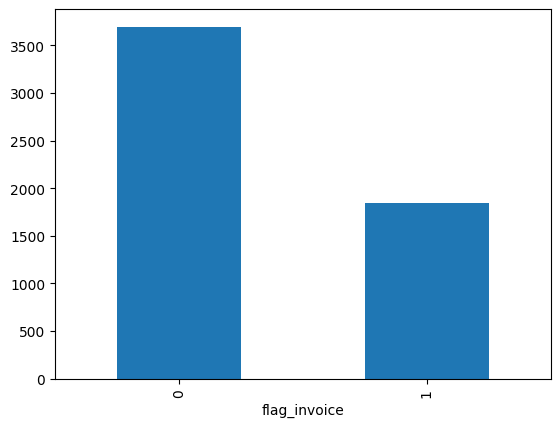

In [32]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

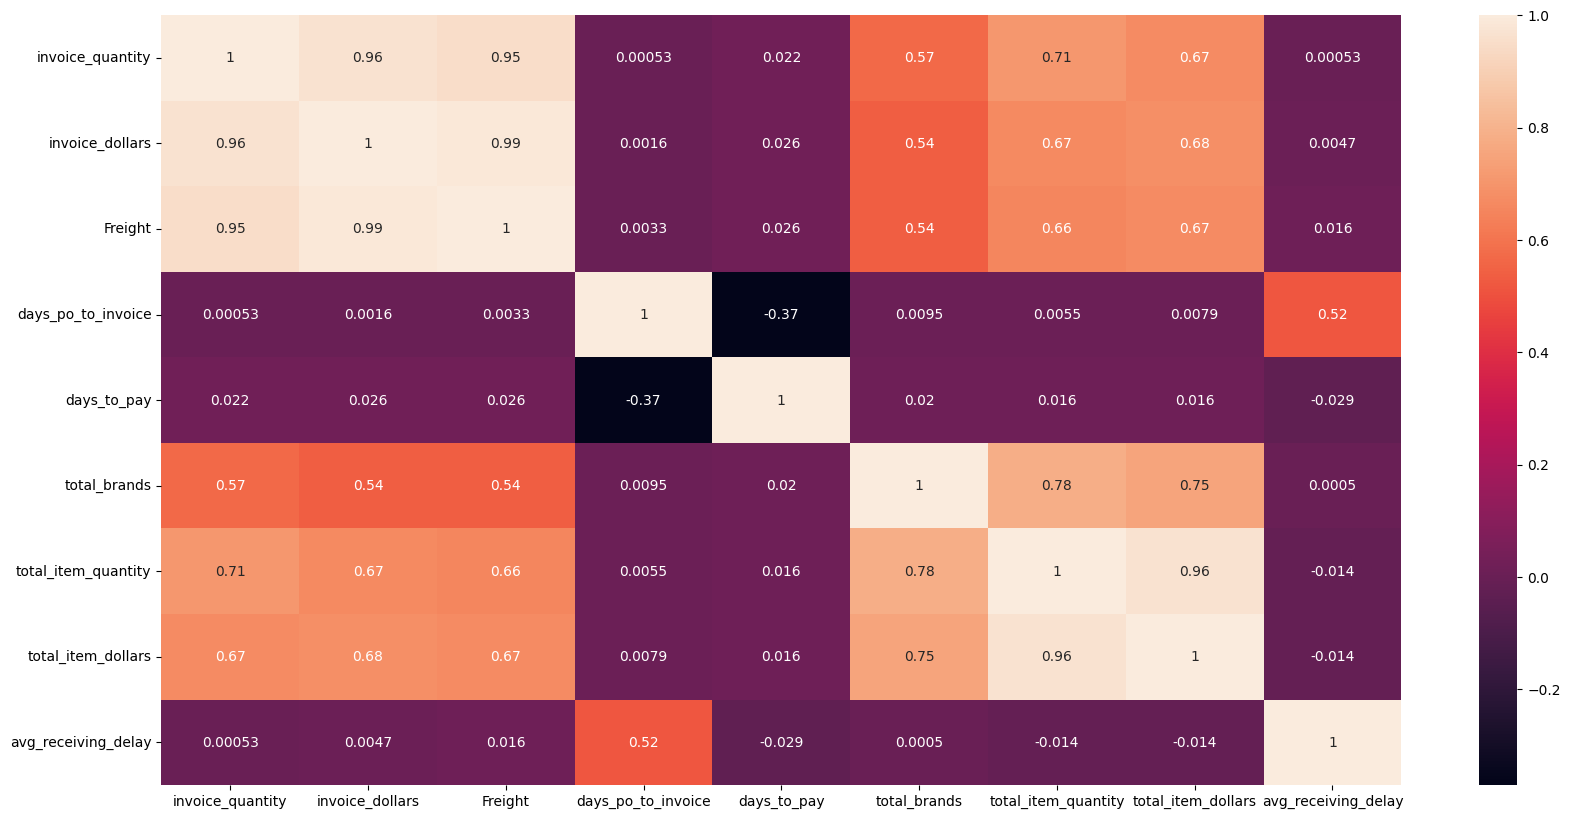

In [33]:
# creating correlation plot

plt.figure(figsize = (20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot = True)
plt.show()

## Hypothesis Testing: T-Test

We are performing a **t-test** to statistically determine whether there is a significant difference in key metrics (such as costs or delays) between **flagged (high-risk)** and **normal invoices**.

### This helps in:

- **Feature Validation:**  
  Helps confirm which features genuinely distinguish risky invoices from normal ones.

- **Data-Driven Feature Selection:**  
  Features showing statistically significant differences are strong candidates for the machine learning model, while non-significant features can be removed to reduce noise and improve model efficiency.

In [11]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [12]:
significant_features = []
nonsignificant_features = []
results = []

In [13]:
# the metrics we need to compare
metrics = ['invoice_quantity',
'invoice_dollars',
'Freight',
'days_po_to_invoice',
'days_to_pay',
'total_brands',
'total_item_quantity',
'total_item_dollars',
'avg_receiving_delay']

In [14]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_val = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False     #because we aren't assuming the variances of the 'flagged' and 'normal' invoice groups are equal
    )

    if p_val < 0.05:
        significant_features.append(metric)
        results.append({
            "metric" : metric,
            "flagged_mean" : float(flagged_mean.round(2)),
            "normal_mean" : float(normal_mean.round(2)),
            "p_value" : float(p_val.round(2))
        })
    else :
        nonsignificant_features.append(metric) 
        print(metric)
        print({
            "metric" : metric,
            "flagged_mean" : float(flagged_mean.round(2)),
            "normal_mean" : float(normal_mean.round(2)),
            "p_val" : float(p_val.round(2))
        })


days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': 35.43, 'normal_mean': 35.49, 'p_val': 0.73}
total_brands
{'metric': 'total_brands', 'flagged_mean': 42.26, 'normal_mean': 40.84, 'p_val': 0.52}


In [15]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6723.52,
  'normal_mean': 5726.47,
  'p_value': 0.02},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65506.23,
  'normal_mean': 54355.95,
  'p_value': 0.01},
 {'metric': 'Freight',
  'flagged_mean': 333.51,
  'normal_mean': 277.17,
  'p_value': 0.01},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6723.52,
  'normal_mean': 5726.47,
  'p_value': 0.02},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65506.23,
  'normal_mean': 54355.95,
  'p_value': 0.01},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [16]:
features = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars']
target = 'flag_invoice'
x = df[features]
y = df[target]

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
x.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0


In [19]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler, RobustScaler
scaler = RobustScaler()
x_train_scaled  = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [21]:
model_1 = LogisticRegression(random_state=42)
model_1.fit(x_train_scaled, y_train)

model_2 = DecisionTreeClassifier(random_state=42)
model_2.fit(x_train_scaled, y_train)

model_3 =RandomForestClassifier(random_state=42)
model_3.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
from sklearn.metrics import classification_report, accuracy_score
def evaluate_model(model, x_test_scaled, y_test, model_name):

    y_pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    print(f"\nModel Evaluation: {model_name}")
    print("=" * 40)
    print(f"Accuracy: {acc:.4f}")
    print("-" * 60)
    print(df_report)
    print("=" * 60)


In [23]:
evaluate_model(model_1, x_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model_2, x_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model_3, x_test_scaled, y_test, 'Random Forest Classifier')


Model Evaluation: Logistic Regression
Accuracy: 0.6601
------------------------------------------------------------
              precision    recall  f1-score      support
0              0.662313  0.979310  0.790206   725.000000
1              0.594595  0.057292  0.104513   384.000000
accuracy       0.660054  0.660054  0.660054     0.660054
macro avg      0.628454  0.518301  0.447359  1109.000000
weighted avg   0.638865  0.660054  0.552779  1109.000000

Model Evaluation: Decision Tree Classifier
Accuracy: 0.8215
------------------------------------------------------------
              precision    recall  f1-score      support
0              0.854643  0.875862  0.865123   725.000000
1              0.754098  0.718750  0.736000   384.000000
accuracy       0.821461  0.821461  0.821461     0.821461
macro avg      0.804371  0.797306  0.800561  1109.000000
weighted avg   0.819829  0.821461  0.820413  1109.000000

Model Evaluation: Random Forest Classifier
Accuracy: 0.8765
----------------

In [24]:
feature_importance = pd.DataFrame({
    "feature" : x_train.columns,
    "importance" : model_3.feature_importances_
}).sort_values(by="importance", ascending = False)

feature_importance

,feature,importance
5,total_item_dollars,0.266281
4,total_item_quantity,0.205821
1,invoice_dollars,0.157152
0,invoice_quantity,0.149487
2,Freight,0.145479
3,days_po_to_invoice,0.075780


In [25]:
#we can remove days_po_to_invoice as it has low feature_importance
features = ['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']
target = 'flag_invoice'

In [26]:
x = df[features]
y = df[target]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train_scaled  = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model_3 =RandomForestClassifier(random_state=42)
model_3.fit(x_train_scaled, y_train)

evaluate_model(model_3, x_test_scaled, y_test, 'Random Forest Classifier')


Model Evaluation: Random Forest Classifier
Accuracy: 0.8837
------------------------------------------------------------
              precision    recall  f1-score      support
0              0.864303  0.975172  0.916397   725.000000
1              0.938144  0.710938  0.808889   384.000000
accuracy       0.883679  0.883679  0.883679     0.883679
macro avg      0.901224  0.843055  0.862643  1109.000000
weighted avg   0.889871  0.883679  0.879171  1109.000000


In [27]:
from sklearn.metrics import f1_score,make_scorer
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 4, 5, 6, 7],
    "min_samples_split" : [2, 3, 5],
    "min_samples_leaf" : [1, 2, 5],
    "criterion" : ['gini', 'entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)   
grid_search.fit(x_train_scaled,y_train)
evaluate_model(grid_search, x_test_scaled, y_test, 'Random Forest Classifier')


Fitting 5 folds for each of 270 candidates, totalling 1350 fits

Model Evaluation: Random Forest Classifier
Accuracy: 0.8900
------------------------------------------------------------
              precision    recall  f1-score      support
0              0.866343  0.983448  0.921189   725.000000
1              0.958042  0.713542  0.817910   384.000000
accuracy       0.889991  0.889991  0.889991     0.889991
macro avg      0.912192  0.848495  0.869550  1109.000000
weighted avg   0.898094  0.889991  0.885428  1109.000000


In [28]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid_search.predict(x_test_scaled),y_test)

array([[713, 110],
       [ 12, 274]])

In [29]:
confusion_matrix(model_3.predict(x_test_scaled), y_test)

array([[707, 111],
       [ 18, 273]])

In [30]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}